In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline


# reading the qc file
qc_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\QC_msmetrix.xlsx",
    sheet_name=0,
    header=12
)

print(qc_data.head())



   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041                69053                62942  ...   
3               296333

In [2]:
qc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   ID Names               589 non-null    object 
 6   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 7   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 8   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 9   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 10  s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 11  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 12  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 13  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 14  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 15  s10 S9

# Data preparation

# Getting missing values

In [3]:
qc_data.isnull().sum()

Peak                     0
tR1                      0
tR2                      0
tR                       0
m/z                      0
ID Names                 0
s1 S96_QC1_B1_D1_T1      0
s2 S96_QC2_B1_D1_T1      0
s3 S96_QC3_B1_D1_T1      0
s4 S96_QC4_B1_D1_T1      0
s5 S96_QC1_B1_D2_T1      0
s6 S96_QC2_B1_D2_T1      0
s7 S96_QC3_B1_D2_T1      0
s8 S96_QC4_B1_D2_T1      0
s9 S96_QC1_B1_D3_T1      0
s10 S96_QC2_B1_D3_T1     0
s11 S96_QC3_B1_D3_T1     0
s12 S96_QC4_B1_D3_T1     0
s13 S96_QC2_B1_D4_T1     0
s14 S96_QC3_B1_D4_T1     0
s15 S96_QC4_B1_D4_T1     0
s16 S96_QC1_B1_D4_T1     0
s17 S96_QC1_B1_D5_T1     0
s18 S96_QC1_B1_D9_T1     0
s19 S96_QC2_B1_D5_T1     0
s20 S96_QC2_B1_D9_T1     0
s21 S96_QC3_B1_D5_T1     0
s22 S96_QC3_B1_D9_T1     0
s23 S96_QC4_B1_D5_T1     0
s24 S96_QC4_B1_D9_T1     0
s25 S96_QC1_B1_D10_T1    0
s26 S96_QC1_B1_D6_T1     0
s27 S96_QC1_B1_D7_T1     0
s28 S96_QC1_B1_D8_T1     0
s29 S96_QC3_B1_D10_T1    0
s30 S96_QC3_B1_D6_T1     0
s31 S96_QC3_B1_D7_T1     0
s

In [4]:

# Compute the pairwise differences 
diff_t_vs_1 = (qc_data['tR'] - qc_data['tR1']).abs()
diff_t_vs_2 = (qc_data['tR'] - qc_data['tR2']).abs()
diff_1_vs_2 = (qc_data['tR1'] - qc_data['tR2']).abs()
avg_t   = (qc_data['tR1'] + qc_data['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# Summarize
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [5]:
# put tr_best instead of other tr
qc_data['tR_best'] = (qc_data['tR1'] + qc_data['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()

# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]

# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z                                           ID Names  \
0     1   1.9065   40    0.15%  || 40                                ...   
1     2   1.9480   44    1.81%  || 44                                ...   
2     3   1.9640   81    0.14%  || 81   69  169  119                 ...   
3     4   1.9895   64    0.80%  || 64   48   61   66   96   37  131  ...   
4     5   2.0250   42    0.82%  || 42  41  40  39  38  50            ...   

   s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
0                44728                46928                46096   
1               354392               461936               609704   
2                75703                27041                69053   
3               238856               296333               363394   
4               207592               197912               201184   

   s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  s6 S96_QC2_B1_D2_T1  ...  \
0                44488            

# Peak detection for for qc data

In [8]:
# Define known alkanes with accurate retention time (tR)
alkanes = [
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
]

# Convert to DataFrame
alkane_df = pd.DataFrame(alkanes)

# Set tighter tolerance for GC-MS matching
tr_tol = 0.2  # try 0.2 min window
mz_tol = 2    # use ±2 m/z

# Matching function
def match_alkane(row):
    for _, alk in alkane_df.iterrows():
        if abs(row['tR_best'] - alk['tR']) <= tr_tol:
            return alk['Compound']
    return 'Unknown'

# Apply to your QC GC-MS DataFrame
cleaned_qc['Matched_Compound'] = cleaned_qc.apply(match_alkane, axis=1)

# Show matches
matched = cleaned_qc[cleaned_qc['Matched_Compound'] != 'Unknown']
display(matched[['Peak', 'tR_best', 'm/z', 'Matched_Compound']])


,Peak,tR_best,m/z,Matched_Compound
67,68,5.1565,133,Octane
68,69,5.1760,149,Octane
69,70,5.3015,85,Octane
70,71,5.3270,43,Octane
71,72,5.4685,97,Octane
...,...,...,...,...
571,572,22.9020,85,Eicosane
572,573,22.9315,208,Eicosane
573,574,22.9695,57,Eicosane
574,575,22.9960,73,Eicosane


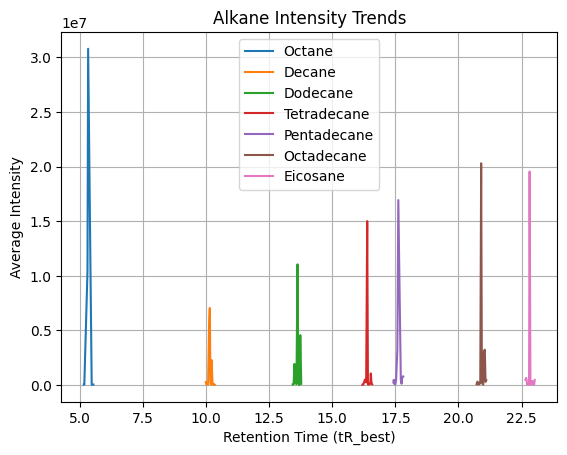

In [9]:
# Select only numeric intensity columns
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Plot mean intensity for each matched compound
for compound in cleaned_qc['Matched_Compound'].unique():
    if compound != 'Unknown':
        subset = cleaned_qc[cleaned_qc['Matched_Compound'] == compound]
        avg_intensity = subset[intensity_cols].mean(axis=1)
        plt.plot(subset['tR_best'], avg_intensity, label=compound)

plt.xlabel('Retention Time (tR_best)')
plt.ylabel('Average Intensity')
plt.title('Alkane Intensity Trends')
plt.legend()
plt.grid(True)
plt.show() 

#  Checking the intensity stability of qcs (containing the above compounds)

In [ ]:

# the master table includes the information related to the samples and qc and their injection order and other metadata like shown bellow. 
file_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
metadata = pd.read_csv(file_path)
print("\nAll column names and types:")
print(metadata.dtypes)


All column names and types:
#                    int64
Filename            object
Sample              object
Block              float64
Plot               float64
Sample_order       float64
Sample_date        float64
Rep                  int64
Day                  int64
Injection_order      int64
Blender            float64
Tenax              float64
Remark             float64
Scan tenax         float64
Check              float64
dtype: object


# Preparing and Aligning QC4 Sample Intensities with Metadata for Analysis

We clean and match QC4 sample names from metadata and intensity data, extract only QC4-related intensity columns, reshape the data to long format, and merge it with injection order information for further analysis

In [ ]:

# clean metadata
metadata = metadata.rename(columns=lambda x: x.strip())

# Extract base sample name from Filename of qc4 
metadata['Filename_clean'] = metadata['Filename'].str.extract(r'(S96_QC4_B1_D\d+_T1)', expand=False)

# Keeping only valid rows
meta_qc4 = metadata[metadata['Filename_clean'].notna()]

# Prepare QC data
cleaned_qc = cleaned_qc.rename(columns=lambda x: str(x).strip())

# Get only intensity columns with QC4
sample_cols = [col for col in qc_data.columns if col.startswith('s') and 'QC4' in col]

# Extract clean sample names from those columns to match metadata
rename_map = {}
for col in sample_cols:
    match = re.search(r'(S96_QC4_B1_D\d+_T1)', col)
    if match:
        rename_map[col] = match.group(1)

# Rename columns
qc_intensity = cleaned_qc[['Peak', 'm/z', 'tR_best']].copy()
qc_intensity = pd.concat([qc_intensity,  cleaned_qc[list(rename_map.keys())].rename(columns=rename_map)], axis=1)

# Melt to long format 
long_df = qc_intensity.melt(id_vars=['Peak', 'm/z', 'tR_best'], var_name='Sample', value_name='Intensity')

# Merge with injection order
inj_order_map = meta_qc4.set_index('Filename_clean')['Injection_order'].to_dict()
inj_order_df = pd.DataFrame.from_dict(inj_order_map, orient='index', columns=['Injection_order'])
inj_order_df = inj_order_df.reset_index().rename(columns={'index': 'Sample'})

# Merge to assign injection order to each Sample
long_df = long_df.merge(inj_order_df, on='Sample', how='inner')

print("Samples in long_df:", long_df['Sample'].unique())
print("Injection orders:", long_df['Injection_order'].unique())


Samples in long_df: ['S96_QC4_B1_D1_T1' 'S96_QC4_B1_D2_T1' 'S96_QC4_B1_D3_T1'
 'S96_QC4_B1_D4_T1' 'S96_QC4_B1_D5_T1' 'S96_QC4_B1_D9_T1'
 'S96_QC4_B1_D10_T1' 'S96_QC4_B1_D6_T1' 'S96_QC4_B1_D7_T1'
 'S96_QC4_B1_D8_T1']
Injection orders: [  7  39  69  99 131 255 285 161 191 223]


# Assessing Signal Stability of QC4 Peaks Using %RSD Analysis

We reshape QC4 intensity data, link it with injection order, calculate the %RSD (relative standard deviation) for each peak to assess signal stability, and visualize the top 10 most stable peaks across injections and also listed them.

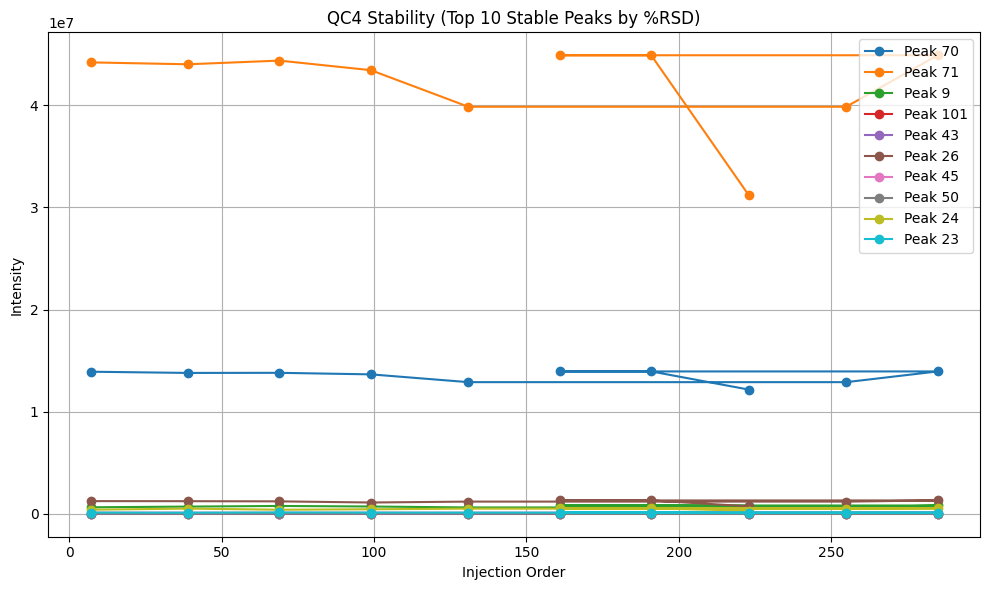

Top 10 Stable Peaks (%RSD):


,Peak,Mean_Intensity,STD_Intensity,%RSD
69,70,13493404.3,6.216100e+05,4.606769
70,71,42156262.0,4.310598e+06,10.225284
8,9,732760.0,8.010202e+04,10.931550
100,101,5162.9,6.538203e+02,12.663819
42,43,27068.1,3.836037e+03,14.171802
25,26,1189007.4,1.700062e+05,14.298164
44,45,116421.3,1.778044e+04,15.272499
49,50,17974.9,2.824307e+03,15.712506
23,24,469693.6,7.651021e+04,16.289387
22,23,116008.1,1.899606e+04,16.374774


In [ ]:
# Create a new DataFrame with only needed columns and renamed sample columns
intensity_matched =  cleaned_qc[['Peak', 'm/z', 'ID Names', 'tR_best']].copy()
intensity_matched = pd.concat(
    [intensity_matched,  cleaned_qc[list(rename_map.keys())].rename(columns=rename_map)],
    axis=1
)
# Add injection order 
inj_order_map = meta_qc4.set_index('Filename_clean')['Injection_order'].to_dict()
inj_order_df = pd.DataFrame.from_dict(inj_order_map, orient='index', columns=['Injection_order']).reset_index()
inj_order_df = inj_order_df.rename(columns={'index': 'Sample'})

# Melt data to long format
long_df = intensity_matched.melt(
    id_vars=['Peak', 'm/z', 'ID Names', 'tR_best'],
    var_name='Sample',
    value_name='Intensity'
)

# Merge injection order
long_df = long_df.merge(inj_order_df, on='Sample')
#  %RSD calculation 
rsd_df = long_df.groupby('Peak').agg({'Intensity': ['mean', 'std']})
rsd_df.columns = ['Mean_Intensity', 'STD_Intensity']
rsd_df['%RSD'] = 100 * rsd_df['STD_Intensity'] / rsd_df['Mean_Intensity']
rsd_df = rsd_df.reset_index()

# Plot Top 5 Stable Peaks 
top5_peaks = rsd_df.sort_values('%RSD').head(10)['Peak'].tolist()

plt.figure(figsize=(10, 6))
for peak_id in top5_peaks:
    subset = long_df[long_df['Peak'] == peak_id]
    plt.plot(subset['Injection_order'], subset['Intensity'], marker='o', label=f'Peak {peak_id}')

plt.xlabel('Injection Order')
plt.ylabel('Intensity')
plt.title('QC4 Stability (Top 10 Stable Peaks by %RSD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Output Top 10 Stable Peaks 
print("Top 10 Stable Peaks (%RSD):")
display(rsd_df.sort_values('%RSD').head(10))

The plot visually confirms stability trends, showing nearly flat intensity lines for stable peaks.

Peak 70 is the most stable, with a %RSD of 4.61%, indicating high reproducibility. Therefore, it is suitable for use as a normalization reference for the samples.

# Normalization

we're averaging intensities for the same compound across similar QC samples, so the values are already on the same scale. Since it's just repeated measurements of one feature, there's no need to normalize — averaging already handles the small variations.  but we will do log transformation to remove the skewness

# Log‐transform / variance stabilization

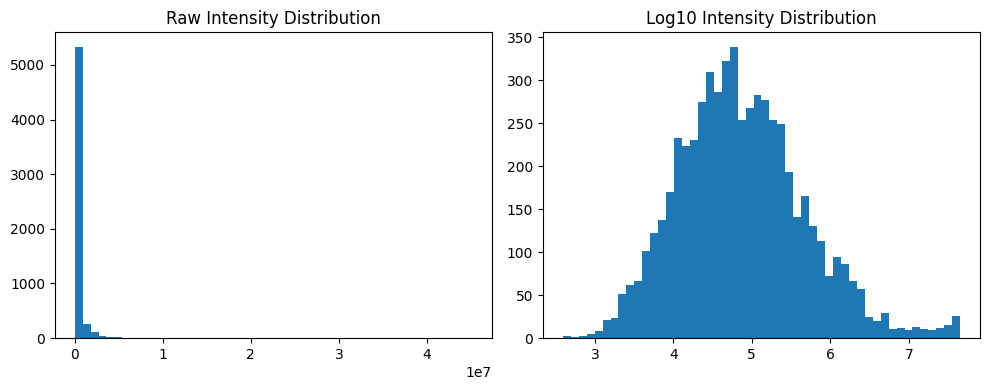

In [ ]:
# Use raw intensity values
raw_intensity = long_df['Intensity'][long_df['Intensity'] > 0]

# Histogram
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(raw_intensity, bins=50)
plt.title("Raw Intensity Distribution")

# Log-transformed histogram
plt.subplot(1, 2, 2)
plt.hist(np.log10(raw_intensity), bins=50)
plt.title("Log10 Intensity Distribution")
plt.tight_layout()
plt.show()

# check skewness

In [ ]:
from scipy.stats import skew

print("Raw skewness:", skew(raw_intensity))
print("Log-transformed skewness:", skew(np.log10(raw_intensity)))


Raw skewness: 8.989652142508099
Log-transformed skewness: 0.5049230853580002


log transformation is definitely needed.
It significantly reduces skewness and will make data more suitable for visualization and statistical analysis like PCA or clustering.

# Log Transformation and Normalization of QC4 Intensities Using Peak 70 as Reference

In [ ]:
# Extract Peak 70 from cleaned QC and get QC4 columns only 
peak70_qc = cleaned_qc[cleaned_qc['Peak'] == 70]

# Define metadata columns
metadata_cols = ['Peak', 'm/z', 'ID Names', 'tR_best']

# Create tidy QC4 dataframe 
qc4_cols = [col for col in cleaned_qc.columns if 'QC4' in col and col not in metadata_cols]

# Calculate the average Peak 70 intensity from QC4 
qc4_peak70_mean = peak70_qc[qc4_cols].mean(axis=1).values[0]

# Melt QC data into long format
qc_tidy = cleaned_qc.melt(
    id_vars=metadata_cols,
    value_vars=qc4_cols,
    var_name='Sample',
    value_name='Intensity'
).dropna(subset=['Intensity'])

# Ensure intensity is numeric
qc_tidy['Intensity'] = pd.to_numeric(qc_tidy['Intensity'], errors='coerce')

# Log-transform intensity values
qc_tidy['Log_Intensity'] = np.log10(qc_tidy['Intensity'].replace(0, np.nan))

# Calculate log-transformed Peak 70 mean
log_peak70_mean = np.log10(float(qc4_peak70_mean))

# Normalize in log space
qc_tidy['Log_Normalized_Intensity'] = qc_tidy['Log_Intensity'] - log_peak70_mean
qc_tidy.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\qc_tidy_log_normalized.csv", index=False)


# Outlier identification

Outlier QC samples detected: []


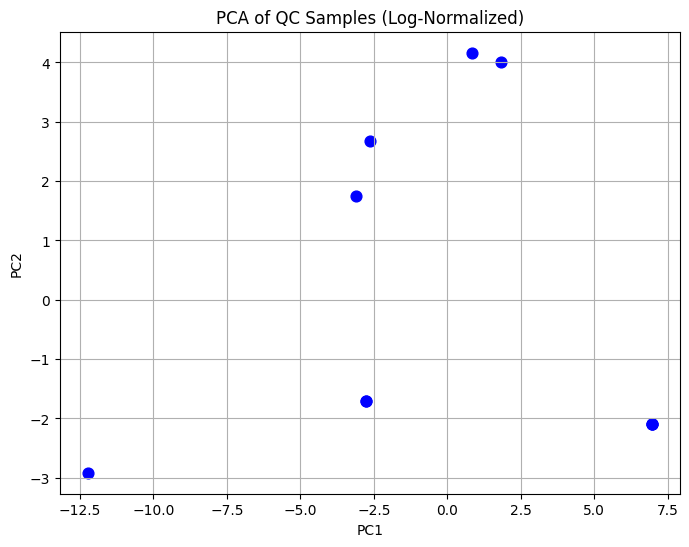

In [ ]:

from sklearn.decomposition import PCA
from scipy.stats import zscore

# Pivot tidy data to wide format 
qc_matrix = qc_tidy.pivot_table(
    index='Sample',
    columns='Peak',
    values='Log_Normalized_Intensity'
)


# outlier detection  by zscore
z_scores = zscore(qc_matrix, axis=0, nan_policy='omit')
z_scores_abs = np.abs(z_scores)
outlier_mask = (z_scores_abs > 3).any(axis=1)

# Print the result
outlier_samples = qc_matrix.index[outlier_mask].tolist()
print(f"Outlier QC samples detected: {outlier_samples}")

#plot pca
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(qc_matrix.fillna(0))

plt.figure(figsize=(8, 6))
for i, sample in enumerate(qc_matrix.index):
    color = 'red' if sample in outlier_samples else 'blue'
    plt.scatter(pca_scores[i, 0], pca_scores[i, 1], c=color, label=sample if i == 0 else "", s=60)

plt.title('PCA of QC Samples (Log-Normalized)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.legend([], frameon=False)
plt.show()

QC4 samples are consistent after peak 70 normalization, no outlier is exist.